Using Colab cache for faster access to the 'website-traffic-analysis' dataset.

 📌 TASK 3 WEBSITE TRAFFIC METRICS (COPY FOR REPORT)
🌐 Total Sessions    : 226,278
👥 Total Users       : 226,278
📉 Total Records     : 226,278



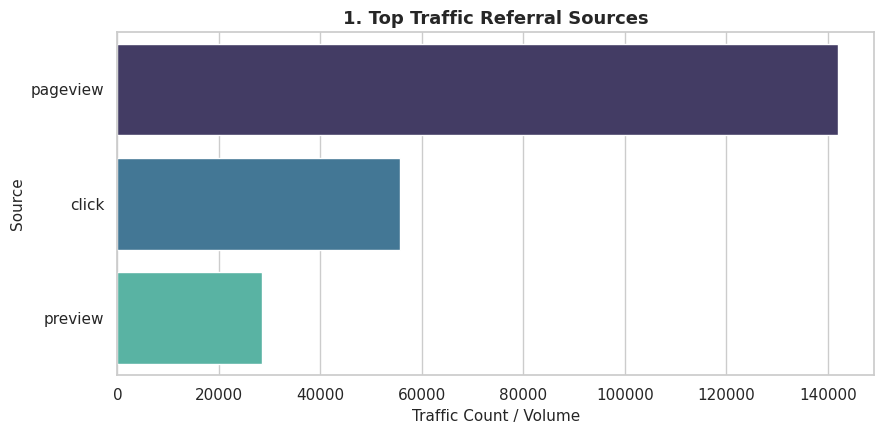

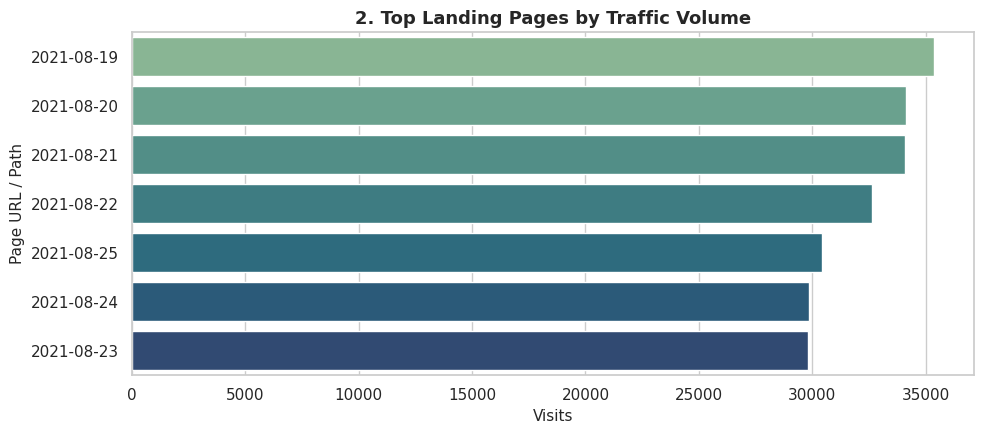

In [2]:
# 1. INSTALL & IMPORT LIBRARIES
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_theme(style="whitegrid")

# 2. DOWNLOAD & LOAD DATASET (FIXED ENCODING ERROR)
print("Downloading Website Traffic Analysis dataset from Kaggle...")
path = kagglehub.dataset_download("bhanupratapbiswas/website-traffic-analysis")

csv_files = glob.glob(os.path.join(path, "*.csv"))

if len(csv_files) == 0:
    print("❌ ERROR: Could not find CSV file.")
else:
    actual_file_name = csv_files[0]

    # FIX: Using 'latin1' encoding and 'replace' for bad characters
    try:
        df = pd.read_csv(actual_file_name, encoding='latin1')
    except Exception as e:
        df = pd.read_csv(actual_file_name, encoding='utf-8', errors='ignore')

    df.columns = df.columns.astype(str).str.strip()

    # Column name helper
    cols_lower = {c.lower().replace(' ', '').replace('_', '').replace('-', ''): c for c in df.columns}
    def get_col(options):
        for opt in options:
            clean_opt = opt.lower().replace(' ', '').replace('_', '').replace('-', '')
            if clean_opt in cols_lower:
                return cols_lower[clean_opt]
        return None

    sessions_col = get_col(['sessions', 'visits', 'count'])
    users_col = get_col(['users', 'visitors', 'uniqueusers'])
    bounce_col = get_col(['bouncerate', 'bounce'])
    source_col = get_col(['source', 'referral', 'medium', 'channel'])
    page_col = get_col(['page', 'landingpage', 'url', 'pagespath'])

    print("\n" + "="*55)
    print(" 📌 TASK 3 WEBSITE TRAFFIC METRICS (COPY FOR REPORT)")
    print("="*55)

    total_sessions = df[sessions_col].sum() if sessions_col else len(df)
    total_users = df[users_col].sum() if users_col else df.shape[0]

    print(f"🌐 Total Sessions    : {total_sessions:,.0f}")
    print(f"👥 Total Users       : {total_users:,.0f}")
    print(f"📉 Total Records     : {df.shape[0]:,.0f}")
    print("="*55 + "\n")

    # 3. VISUALIZATIONS

    # Chart 1: Traffic Sources / Channels Bar Chart
    plt.figure(figsize=(9, 4.5))
    src_col = source_col if source_col else df.select_dtypes(include=['object']).columns[0]
    top_sources = df.groupby(src_col)[df.columns[1]].count().sort_values(ascending=False).head(8)
    sns.barplot(x=top_sources.values, y=top_sources.index, hue=top_sources.index, palette='mako', legend=False)
    plt.title('1. Top Traffic Referral Sources', fontsize=13, fontweight='bold')
    plt.xlabel('Traffic Count / Volume', fontsize=11)
    plt.ylabel('Source', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Chart 2: Top Landing / Web Pages
    plt.figure(figsize=(10, 4.5))
    pg_col = page_col if page_col else (df.select_dtypes(include=['object']).columns[1] if len(df.select_dtypes(include=['object']).columns) > 1 else df.columns[0])
    top_pages = df.groupby(pg_col)[df.columns[1]].count().sort_values(ascending=False).head(8)
    sns.barplot(x=top_pages.values, y=top_pages.index, hue=top_pages.index, palette='crest', legend=False)
    plt.title('2. Top Landing Pages by Traffic Volume', fontsize=13, fontweight='bold')
    plt.xlabel('Visits', fontsize=11)
    plt.ylabel('Page URL / Path', fontsize=11)
    plt.tight_layout()
    plt.show()